# **PONTIFICIA UNIVERSIDAD JAVERIANA**
## **Procesamiento de alto volumen de datos**
**Fecha:** 7 de Abril del 2026

**Autor:** Grupo Sigma

**Tema:** Proyecto de Big Data

**Objetivo:** 
- Entender la importancia del uso de herramientas de Big Data en entornos empresariales, a fin de poder solucionar preguntas de negocio.
- Entender el paso a paso de un proyecto de procesamiento de datos para la generación de hallazgos de valor basado en la metodología CRISP-DM.
- Documentar la implementación de un cluster como infraestructura de procesamiento de grandes volúmenes de datos, a través de máquinas virtuales
- Realizar procesamiento de datos aplicado a un problema real.

**Version:** Entrega 1

Para asegurar que el proyecto funcione correctamente con pandas, matplotlib, seaborn y findspark, ejecutar el siguiente comando desde la raíz del proyecto
```bash
pip install -r requirements.txt
```

In [1]:
### Importación de bibliotecas basicas 
import os                       # -> Para gestion de archivos y procesos
import sys                      # -> Para manejo de recursos del sistema
import pandas as pd             # -> Para graficar y objetos dataframe
import numpy as np              # -> Para algebra matricial
import matplotlib.pyplot as plt # -> Para formatos de graficas
import seaborn as sns           # -> Para estadistica y graficar
import scipy.stats as stats     # -> Para pruebas estadisticas

In [2]:
### Importacion de bibliotecas especializadas
import findspark                                # -> Para manejo del entorno de PySpark
findspark.init('/Almacen/Spark')                # -> Se inicia el entorno para PySpark
from pyspark import SparkConf, SparkContext     # -> Para contexto y configuración de PySpark
from pyspark.sql import SparkSession            # -> Para manejo de Sesion en entorno de consultas SQL
from pyspark.sql.functions import *             # -> Para funciones de manipulacion de columnas
from pyspark.sql.types import IntegerType, StringType, DoubleType # -> Para definir tipos de datos
import pyspark.sql.functions as F               # -> Para funciones de manipulacion de columnas (alias)
from pyspark.ml.feature import VectorAssembler  # -> Para construcción de vectores  
from pyspark.ml.stat import Correlation         # -> Para calculo de correlaciones

In [3]:
configura = SparkConf()
configura.set('spark.scheduler.mode', 'FAIR')
configura.set('spark.scheduler.allocation','/Almacen/Spark/conf/fairscheduler.xml')
configura.setMaster('spark://10.43.97.166:7077')
configura.setAppName('SigmaSPARK')

sparkSigma = SparkSession.builder.config(conf=configura).getOrCreate()
sparkSigma

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/04/08 19:42:17 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/04/08 19:42:18 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.


### Actividades a realizar

- Lectura de data
- Descripción de los datos
- Exploración de los datos
- Reporte de calidad
- Planteamiento de preguntas investigativas
- Limpieza, filtro y transformaciones iniciales

## **Lectura de data**

In [4]:
## Se crea el dataframe para acceder al sistema de fichero csv como un objeto dataframe pyspark
## El acceso se hara desde el sistema de ficheros Hadoop HDFS
dfPy00 = sparkSigma.read.format("csv").option("header","true").load("../data/Beneficiarios_Estrategia_UNIDOS_20260407.csv")
dfPy00.show(5)

26/04/08 19:42:30 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


+-------------+-------------+---------+----+--------------------------+--------------------------+-----------------------+-----------------------+-------------+------------------+---------------+------------+---------------+-------+-----+------+-----------------+-------------+------------------+---------+---------+---------+------------+---------+---------+---------+---------+---------+------------+---------+---------+---------+---------+------------+------------+---------+------------+------------+------------+---------+---------+------------+---------+------------+------------+----+----+----+----+----+----+----+----+------------------+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+
|CodigoFamilia|TipoDocumento|RangoEdad|Pais|CodigoDepartamentoAtencion|NombreDepartamentoAtencion|CodigoMunicipioAtencion|NombreMunicipioAtencion|PuntajeSISBEN|BeneficiarioSISBEN|CondicionSexual|Discapacidad|    EstadoCivil|Estrato|Etnia|Genero|       Parente

## **Descripción de los datos**

**Se hace la introduccion sobre los datos de "Beneficiarios de la estrategia Unidos" de pacientes almacenados sobre datos estructurados "csv"**

### **Análisis de la Fuente de Datos**

Tras la carga inicial del conjunto de datos mediante PySpark, se procede a realizar una interpretación técnica y de negocio de la información disponible. Este dataset permite caracterizar la población en situación de pobreza extrema en Colombia.

#### Resumen de Metadatos

- Nombre del Dataset: Beneficiarios Estrategia UNIDOS.
- Entidad Origen: Departamento Administrativo para la Prosperidad Social (DPS).
- Volumen de Datos: Aproximadamente 1.51 Millones de filas y 73 columnas.
- Granularidad: Cada registro representa a un individuo (beneficiario) perteneciente a un hogar focalizado.

#### Estructura de las Variables

El dataset se organiza en cuatro dimensiones principales:
1. Identificación y Ubicación: Incluye códigos de familia, tipos de documento y ubicación geográfica (Departamento/Municipio) mediante códigos DIVIPOLA.
2. Caracterización Sociodemográfica: Variables como RangoEdad, Genero, Etnia, EstadoCivil y Discapacidad. Es notable la inclusión de CondicionSexual para análisis de diversidad.
3. Seguimiento de Logros (Estrategia UNIDOS): Un bloque de 26 variables (Logro1 a Logro26) que miden el estado de superación de la pobreza (e.g., Alfabetismo, Acceso a Agua, Seguridad Alimentaria).
4. Dimensiones de Salud y Vivienda (Encuesta PE/HE): Variables técnicas que detallan condiciones físicas del hogar (paredes, pisos, hacinamiento) y condiciones de salud específicas.



### **Analisis premilinar**

Al observar las primeras 5 filas del objeto dfPy00, se identifican los siguientes puntos para la fase de Preparación de Datos:
- Valores Nulos y Desconocidos: Se detecta la presencia de etiquetas como ND (No Definido), Sin Información y NULL. Será necesario estandarizar estos valores para no sesgar las estadísticas.
- Tipado de Datos: Aunque columnas como PuntajeSISBEN y Estrato son conceptualmente numéricas, la carga inicial desde CSV a menudo las interpreta como String. Se requiere un casting explícito a IntegerType o DoubleType.
- Codificación de Logros: Las columnas de logros utilizan categorías textuales (ALCANZADO, POR ALCANZAR, NO APLICA). Para modelos analíticos, se sugiere una transformación a variables dummy o escala ordinal.
- Consistencia Geográfica: Las columnas CodigoDepartamentoAtencion y CodigoMunicipioAtencion deben tratarse como cadenas (strings) para preservar los ceros a la izquierda (por ejemplo, 05 para Antioquia).

### **Diagnóstico y tratamiento de datos sobre Pyspark**

- **1** Cambio de nombre de columnas
- **2** Tipos y coherencia de datos
- **3** Identificación y tratamiento de nulos 
- **4** Estadísticas generales
- **5** Categorías y cambio sobre el tipo de datos de las categorías

### 1 - Cambio de nombre de columnas

In [5]:
### Se despliega las columnas
dfPy00.columns

['CodigoFamilia',
 'TipoDocumento',
 'RangoEdad',
 'Pais',
 'CodigoDepartamentoAtencion',
 'NombreDepartamentoAtencion',
 'CodigoMunicipioAtencion',
 'NombreMunicipioAtencion',
 'PuntajeSISBEN',
 'BeneficiarioSISBEN',
 'CondicionSexual',
 'Discapacidad',
 'EstadoCivil',
 'Estrato',
 'Etnia',
 'Genero',
 'Parentesco',
 'TipoPoblacion',
 'EstadoBeneficiario',
 'Logro1',
 'Logro2',
 'Logro3',
 'Logro4',
 'Logro5',
 'Logro6',
 'Logro7',
 'Logro8',
 'Logro9',
 'Logro10',
 'Logro11',
 'Logro12',
 'Logro13',
 'Logro14',
 'Logro15',
 'Logro16',
 'Logro17',
 'Logro18',
 'Logro19',
 'Logro20',
 'Logro21',
 'Logro22',
 'Logro23',
 'Logro24',
 'Logro25',
 'Logro26',
 'PE34',
 'PE35',
 'PE36',
 'PE37',
 'PE38',
 'PE39',
 'PE40',
 'PE41',
 'PE42',
 'PE43',
 'PE44',
 'PE45',
 'PE46',
 'PE48',
 'PE50',
 'PE51',
 'HE11',
 'HE12',
 'HE13',
 'HE14',
 'HE15',
 'HE16',
 'HE17',
 'HE18',
 'HE20',
 'HE21',
 'HE22',
 'HE23']

In [6]:
## Se listan los nombres de las columnas actuales y los nombres por los que deseo cambiar del dataframe  
NombresOriginales = [
    'CodigoFamilia', 'TipoDocumento', 'RangoEdad', 'Pais', 
    'CodigoDepartamentoAtencion', 'NombreDepartamentoAtencion', 
    'CodigoMunicipioAtencion', 'NombreMunicipioAtencion', 
    'PuntajeSISBEN', 'BeneficiarioSISBEN', 'CondicionSexual', 
    'Discapacidad', 'EstadoCivil', 'Estrato', 'Etnia', 
    'Genero', 'Parentesco', 'TipoPoblacion', 'EstadoBeneficiario'
]

NombresNuevos = [
    'ID_FAMILIA', 'TIPO_DOC', 'RANGO_EDAD', 'PAIS', 
    'COD_DEP', 'NOM_DEP', 'COD_MUN', 'NOM_MUN', 
    'PUNTAJE_SISBEN', 'TIENE_SISBEN', 'ORIENT_SEXUAL', 
    'DISCAPACIDAD', 'ESTADO_CIVIL', 'ESTRATO', 'ETNIA', 
    'GENERO', 'PARENTESCO', 'TIPO_POBLACION', 'ESTADO_BENEF'
]

#### Version
### original --> "Cambio de nombres de cada columna"
dfPy01 = dfPy00
for antes, nuevo in zip(NombresOriginales, NombresNuevos):
    dfPy01 = dfPy01.withColumnRenamed(antes, nuevo)

dfPy01.columns

['ID_FAMILIA',
 'TIPO_DOC',
 'RANGO_EDAD',
 'PAIS',
 'COD_DEP',
 'NOM_DEP',
 'COD_MUN',
 'NOM_MUN',
 'PUNTAJE_SISBEN',
 'TIENE_SISBEN',
 'ORIENT_SEXUAL',
 'DISCAPACIDAD',
 'ESTADO_CIVIL',
 'ESTRATO',
 'ETNIA',
 'GENERO',
 'PARENTESCO',
 'TIPO_POBLACION',
 'ESTADO_BENEF',
 'Logro1',
 'Logro2',
 'Logro3',
 'Logro4',
 'Logro5',
 'Logro6',
 'Logro7',
 'Logro8',
 'Logro9',
 'Logro10',
 'Logro11',
 'Logro12',
 'Logro13',
 'Logro14',
 'Logro15',
 'Logro16',
 'Logro17',
 'Logro18',
 'Logro19',
 'Logro20',
 'Logro21',
 'Logro22',
 'Logro23',
 'Logro24',
 'Logro25',
 'Logro26',
 'PE34',
 'PE35',
 'PE36',
 'PE37',
 'PE38',
 'PE39',
 'PE40',
 'PE41',
 'PE42',
 'PE43',
 'PE44',
 'PE45',
 'PE46',
 'PE48',
 'PE50',
 'PE51',
 'HE11',
 'HE12',
 'HE13',
 'HE14',
 'HE15',
 'HE16',
 'HE17',
 'HE18',
 'HE20',
 'HE21',
 'HE22',
 'HE23']

In [7]:
dfPy01.show(5)

[Stage 2:>                                                          (0 + 1) / 1]

+-----------+--------+----------+----+-------+---------+-------+-------+--------------+------------+-------------+------------+---------------+-------+-----+------+-----------------+--------------+------------+---------+---------+---------+------------+---------+---------+---------+---------+---------+------------+---------+---------+---------+---------+------------+------------+---------+------------+------------+------------+---------+---------+------------+---------+------------+------------+----+----+----+----+----+----+----+----+------------------+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+
| ID_FAMILIA|TIPO_DOC|RANGO_EDAD|PAIS|COD_DEP|  NOM_DEP|COD_MUN|NOM_MUN|PUNTAJE_SISBEN|TIENE_SISBEN|ORIENT_SEXUAL|DISCAPACIDAD|   ESTADO_CIVIL|ESTRATO|ETNIA|GENERO|       PARENTESCO|TIPO_POBLACION|ESTADO_BENEF|   Logro1|   Logro2|   Logro3|      Logro4|   Logro5|   Logro6|   Logro7|   Logro8|   Logro9|     Logro10|  Logro11|  Logro12|  Logro13

### 2 - Tipos y coherencia de datos

In [8]:
#### -----> Func
dfPy01.printSchema()

root
 |-- ID_FAMILIA: string (nullable = true)
 |-- TIPO_DOC: string (nullable = true)
 |-- RANGO_EDAD: string (nullable = true)
 |-- PAIS: string (nullable = true)
 |-- COD_DEP: string (nullable = true)
 |-- NOM_DEP: string (nullable = true)
 |-- COD_MUN: string (nullable = true)
 |-- NOM_MUN: string (nullable = true)
 |-- PUNTAJE_SISBEN: string (nullable = true)
 |-- TIENE_SISBEN: string (nullable = true)
 |-- ORIENT_SEXUAL: string (nullable = true)
 |-- DISCAPACIDAD: string (nullable = true)
 |-- ESTADO_CIVIL: string (nullable = true)
 |-- ESTRATO: string (nullable = true)
 |-- ETNIA: string (nullable = true)
 |-- GENERO: string (nullable = true)
 |-- PARENTESCO: string (nullable = true)
 |-- TIPO_POBLACION: string (nullable = true)
 |-- ESTADO_BENEF: string (nullable = true)
 |-- Logro1: string (nullable = true)
 |-- Logro2: string (nullable = true)
 |-- Logro3: string (nullable = true)
 |-- Logro4: string (nullable = true)
 |-- Logro5: string (nullable = true)
 |-- Logro6: string 

In [9]:
import pyspark.sql.functions as F

# Inicializamos el dataframe de transformación
dfPy02 = dfPy01

# 1. Tratamiento de Variables Numéricas (Casting)
columnas_a_entero = ['ESTRATO', 'PUNTAJE_SISBEN', 'HE17', 'HE18']
for col_name in columnas_a_entero:
    dfPy02 = dfPy02.withColumn(col_name, F.col(col_name).cast("int"))

# 2. Tratamiento de Logros (Mapeo a Enteros 1, 0, -1)
logros_cols = [c for c in dfPy02.columns if c.startswith('Logro')]

for c in logros_cols:
    dfPy02 = dfPy02.withColumn(c, 
        F.when(F.col(c) == "ALCANZADO", 1)
        .when(F.col(c) == "POR ALCANZAR", 0)
        .when(F.col(c) == "NO APLICA", -1)
        .otherwise(None).cast("int") 
    )

# 3. Tratamiento de Preguntas PE y HE (Si/No a Booleano)
preguntas_cols = [c for c in dfPy02.columns if c.startswith('PE') or c.startswith('HE')]
excluir = ['PE42', 'HE17', 'HE18', 'HE20']
bool_cols = [c for c in preguntas_cols if c not in excluir]

for c in bool_cols:
    dfPy02 = dfPy02.withColumn(c, 
        F.when(F.col(c) == "Si", True)
        .when(F.col(c) == "No", False)
        .otherwise(None).cast("boolean")
    )

# 4. Limpieza de caracteres especiales y normalización
dfPy02 = dfPy02.withColumn("ESTADO_CIVIL", F.regexp_replace(F.col("ESTADO_CIVIL"), "InformaciÃ³n", "Información"))

# 5. Estandarización de texto (Mayúsculas y quitar espacios en blanco)
columnas_texto = ['TIPO_DOC', 'NOM_DEP', 'NOM_MUN', 'PARENTESCO', 'ETNIA', 'ESTADO_CIVIL']
for c in columnas_texto:
    dfPy02 = dfPy02.withColumn(c, F.upper(F.trim(F.col(c))))

# 6. Corrección masiva de caracteres especiales (Encoding)
correcciones = {
    "Ã³": "O", "Ã±": "N", "Ã¡": "A", "Ã©": "E", "Ã­": "I", "Â°": "", "Ãº": "U"
}

# Columnas específicas a corregir
cols_to_fix = ["ESTADO_CIVIL", "PARENTESCO", "NOM_MUN", "PE42"]

for error, correccion in correcciones.items():
    for c in cols_to_fix:
        dfPy02 = dfPy02.withColumn(c, F.regexp_replace(F.col(c), error, correccion))

# 7. Conversión de "ND" a Nulos reales
for c in dfPy02.columns:
    dfPy02 = dfPy02.withColumn(c, F.when(F.col(c) == "ND", None).otherwise(F.col(c)))

# 8. Ajuste final a la Discapacidad (Booleano)
dfPy02 = dfPy02.withColumn("DISCAPACIDAD", 
    F.when(F.col("DISCAPACIDAD") == "SI", True)
    .when(F.col("DISCAPACIDAD") == "NO", False)
    .otherwise(None).cast("boolean")
)

# Visualización del esquema final
dfPy02.printSchema()

root
 |-- ID_FAMILIA: string (nullable = true)
 |-- TIPO_DOC: string (nullable = true)
 |-- RANGO_EDAD: string (nullable = true)
 |-- PAIS: string (nullable = true)
 |-- COD_DEP: string (nullable = true)
 |-- NOM_DEP: string (nullable = true)
 |-- COD_MUN: string (nullable = true)
 |-- NOM_MUN: string (nullable = true)
 |-- PUNTAJE_SISBEN: integer (nullable = true)
 |-- TIENE_SISBEN: string (nullable = true)
 |-- ORIENT_SEXUAL: string (nullable = true)
 |-- DISCAPACIDAD: boolean (nullable = true)
 |-- ESTADO_CIVIL: string (nullable = true)
 |-- ESTRATO: integer (nullable = true)
 |-- ETNIA: string (nullable = true)
 |-- GENERO: string (nullable = true)
 |-- PARENTESCO: string (nullable = true)
 |-- TIPO_POBLACION: string (nullable = true)
 |-- ESTADO_BENEF: string (nullable = true)
 |-- Logro1: integer (nullable = true)
 |-- Logro2: integer (nullable = true)
 |-- Logro3: integer (nullable = true)
 |-- Logro4: integer (nullable = true)
 |-- Logro5: integer (nullable = true)
 |-- Logro6:

#### **Codificación Ternaria de Logros**

Para las variables de la Estrategia UNIDOS (Logro1 a Logro26), se ha implementado una lógica de codificación numérica que permite distinguir tres estados fundamentales sin perder información por valores nulos:
| Valor Original | Valor Numérico | Significado Analítico |
| :--- | :---: | :--- |
| **ALCANZADO** | $1$ | Objetivo cumplido exitosamente. |
| **POR ALCANZAR** | $0$ | Objetivo pendiente (Foco de intervención). |
| **NO APLICA** | $-1$ | Excluido por perfil (Por ejemplo, logro de lactancia en hombres). |

#### **Optimización de Memoria y Rendimiento**

- Booleanos: Las variables de respuesta directa (Si/No) se han convertido a tipos lógicos. En PySpark, esto reduce el almacenamiento comparado con cadenas de texto. Se incluyó la columna DISCAPACIDAD en esta lógica.
- Manejo de Nulos: Al mapear "NO APLICA" a −1, se reservan los valores null estrictamente para datos faltantes o errores de captura. Adicionalmente, se transformaron los valores de texto "ND" (No Disponible) a nulos reales para no sesgar las estadísticas.
- Casting Numérico: Casting Numérico: Las variables de infraestructura (HE17, HE18), el PUNTAJE_SISBEN y el ESTRATO ahora permiten operaciones matemáticas directas (promedios, sumas y cálculos de hacinamiento).

#### **Normalización de Texto**

- Estandarización de Categorías: Se aplicó una transformación a mayúsculas (UPPER) y eliminación de espacios (TRIM) en variables críticas como PARENTESCO, NOM_MUN y ESTADO_CIVIL. Esto evita la duplicidad de grupos causada por diferencias en la digitación (ej. "Jefe" vs "JEFE").
- Corrección de Encoding (UTF-8): Se implementó una limpieza masiva mediante expresiones regulares para corregir caracteres rotos provenientes del origen de datos. Se normalizaron términos como "CONYUGE", "INFORMACION", "TECNICO" y nombres de municipios con eñes o tildes.
- Integridad Territorial: Se estandarizaron los códigos y nombres de departamentos/municipios para asegurar que los análisis geoespaciales posteriores sean precisos.

In [10]:
dfPy02.show(5)

+-----------+--------+----------+----+-------+---------+-------+-------+--------------+------------+-------------+------------+---------------+-------+-----+------+-----------------+--------------+------------+------+------+------+------+------+------+------+------+------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+----+-----+-----+-----+-----+-----+-----+-----+------------------+-----+-----+-----+-----+-----+-----+-----+----+-----+-----+-----+----+-----+----+----+----+-----+-----+-----+
| ID_FAMILIA|TIPO_DOC|RANGO_EDAD|PAIS|COD_DEP|  NOM_DEP|COD_MUN|NOM_MUN|PUNTAJE_SISBEN|TIENE_SISBEN|ORIENT_SEXUAL|DISCAPACIDAD|   ESTADO_CIVIL|ESTRATO|ETNIA|GENERO|       PARENTESCO|TIPO_POBLACION|ESTADO_BENEF|Logro1|Logro2|Logro3|Logro4|Logro5|Logro6|Logro7|Logro8|Logro9|Logro10|Logro11|Logro12|Logro13|Logro14|Logro15|Logro16|Logro17|Logro18|Logro19|Logro20|Logro21|Logro22|Logro23|Logro24|Logro25|Logro26|PE34| 

### 3 - Identificación y tratamiento de nulos 

In [11]:
# Análisis de Frecuencias para Variables Categóricas

# 1. Distribución por Género
print("Distribución por GÉNERO:")
dfPy02.groupby(["GENERO"]).count().show()

# 2. Distribución por Estado Civil
print("Distribución por ESTADO CIVIL:")
dfPy02.groupby(["ESTADO_CIVIL"]).count().show()

# 3. Distribución por Parentesco
print("Distribución por PARENTESCO:")
dfPy02.groupby(["PARENTESCO"]).count().show()

# 4. Distribución por Tipo de Población
print("Distribución por TIPO DE POBLACIÓN:")
dfPy02.groupby(["TIPO_POBLACION"]).count().show()

# 5. Distribución por Discapacidad
print("Distribución por DISCAPACIDAD (Boolean):")
dfPy02.groupby(["DISCAPACIDAD"]).count().show()

# 6. Distribución por Estado del Beneficiario
print("Distribución por ESTADO DEL BENEFICIARIO:")
dfPy02.groupby(["ESTADO_BENEF"]).count().show()

# Validación de Integridad de la Carga
print("-" * 30)
print("TOTAL DE REGISTROS:", dfPy02.count())
print("TOTAL REGISTROS ÚNICOS (DISTINCT):", dfPy02.distinct().count())
print("-" * 30)

# Verificación de nulos
print("REGISTROS SIN ID_FAMILIA (NULOS):")
print(dfPy02.filter(F.col("ID_FAMILIA").isNull()).count())

Distribución por GÉNERO:


+------+------+
|GENERO| count|
+------+------+
|  NULL|   105|
|Hombre|623761|
| Mujer|885885|
+------+------+

Distribución por ESTADO CIVIL:


+---------------+-------+
|   ESTADO_CIVIL|  count|
+---------------+-------+
|SIN INFORMACIÓN|1450669|
|             UL|  12931|
|           NULL|  22386|
|             SO|  14822|
|             CA|   7166|
|             VI|   1589|
|             DI|    188|
+---------------+-------+

Distribución por PARENTESCO:


+--------------------+------+
|          PARENTESCO| count|
+--------------------+------+
|          SOBRINO(A)|   200|
|                TÍOS|   358|
|CÓNYUGE O COMPAÑE...|160315|
|HIJO(A)/ HIJASTRO(A)|   153|
|       YERNO O NUERA|  3188|
|              PADRES| 10526|
|                JEFE|353269|
|             SUEGROS|   917|
|                NULL|106411|
|       OTRO PARIENTE|    98|
|             ABUELOS|   652|
|            PRIMO(A)|    13|
|   HIJOS / HIJASTROS|299496|
|              PRIMOS|   337|
|HIJO(A) / HIJASTR...| 20122|
|       PADRE / MADRE|   556|
|            HERMANOS|  8699|
|       YERNO / NUERA|   108|
|CÓNYUGE O COMPAÑE...|  9655|
|            SOBRINOS|  5239|
+--------------------+------+
only showing top 20 rows

Distribución por TIPO DE POBLACIÓN:


+--------------+------+
|TIPO_POBLACION| count|
+--------------+------+
|   UNIDOS U100|146184|
| UNIDOS ETNICO|   180|
|  UNIDOS RURAL|754177|
| UNIDOS URBANO|487913|
|        UNIDOS|121297|
+--------------+------+

Distribución por DISCAPACIDAD (Boolean):


...

+------------+-------+
|ESTADO_BENEF|  count|
+------------+-------+
|      ACTIVO|1459717|
|   NO ACTIVO|  50034|
+------------+-------+

------------------------------


TOTAL DE REGISTROS: 1509751


TOTAL REGISTROS ÚNICOS (DISTINCT): 1503388
------------------------------
REGISTROS SIN ID_FAMILIA (NULOS):


[Stage 31:==========================================>              (9 + 3) / 12]

0


In [12]:
# Función para validar si es numérico y decidir si usar isnan
def count_missings(df):
    output = []
    for c, dtype in df.dtypes:
        # Si la columna es Double o Float, evaluar isNull e isnan
        if dtype in ["double", "float"]:
            output.append(F.count(F.when(F.col(c).isNull() | F.isnan(F.col(c)), c)).alias(c))
        # Para el resto, solo isNull
        else:
            output.append(F.count(F.when(F.col(c).isNull(), c)).alias(c))
    return output

# Ejecutar el select con la lógica filtrada
dfPy02.select(count_missings(dfPy02)).show()

[Stage 34:===================================================>    (11 + 1) / 12]

+----------+--------+----------+-------+-------+-------+-------+-------+--------------+------------+-------------+------------+------------+-------+-------+------+----------+--------------+------------+------+------+------+------+------+------+------+------+------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+
|ID_FAMILIA|TIPO_DOC|RANGO_EDAD|   PAIS|COD_DEP|NOM_DEP|COD_MUN|NOM_MUN|PUNTAJE_SISBEN|TIENE_SISBEN|ORIENT_SEXUAL|DISCAPACIDAD|ESTADO_CIVIL|ESTRATO|  ETNIA|GENERO|PARENTESCO|TIPO_POBLACION|ESTADO_BENEF|Logro1|Logro2|Logro3|Logro4|Logro5|Logro6|Logro7|Logro8|Logro9|Logro10|Logro11|Logro12|Logro13|Logro14|Logro15|Logro16|Logro17|Logro18|Logro19|Logro20|Logro21|Logro22|Logro23|Logro24|Logro25|Logro26|PE34|PE35|PE36|PE37|PE38|PE39|PE40|PE41|PE42|PE43|PE44|PE

In [13]:
# Total para los cálculos
total_registros = 1509751

print(f"Cantidad total de registros: {total_registros}")

# 1. Porcentaje de Nulos en Género
print(f"Porcentaje registros nulos en GÉNERO: {105 * 100 / total_registros}%")

# 2. Porcentaje de Nulos en Discapacidad
print(f"Porcentaje registros nulos en DISCAPACIDAD: {65751 * 100 / total_registros}%")

# 3. Porcentaje de Nulos en Parentesco
print(f"Porcentaje registros nulos en PARENTESCO: {106411 * 100 / total_registros}%")

# 4. Porcentaje de "Sin Información" en Estado Civil (Inconsistencia)
print(f"Porcentaje de registros SIN INFORMACIÓN en ESTADO CIVIL: {1450669 * 100 / total_registros}%")

# 5. Porcentaje de registros con País Nulo
print(f"Porcentaje registros nulos en PAÍS: {1372841 * 100 / total_registros}%")

# 6. Porcentaje de Etnia Nula
print(f"Porcentaje registros nulos en ETNIA: {1340181 * 100 / total_registros}%")

# 7. Porcentaje de Duplicados
duplicados = 1509751 - 1503388
print(f"Cantidad de registros duplicados: {duplicados}")
print(f"Porcentaje registros duplicados: {duplicados * 100 / total_registros}%")

Cantidad total de registros: 1509751
Porcentaje registros nulos en GÉNERO: 0.006954789233456378%
Porcentaje registros nulos en DISCAPACIDAD: 4.355089017990384%
Porcentaje registros nulos en PARENTESCO: 7.048248353536444%
Porcentaje de registros SIN INFORMACIÓN en ESTADO CIVIL: 96.086639452466%
Porcentaje registros nulos en PAÍS: 90.93161720045227%
Porcentaje registros nulos en ETNIA: 88.76834656840764%
Cantidad de registros duplicados: 6363
Porcentaje registros duplicados: 0.4214602275474565%


### **Analisis de nulos**

Tras ejecutar el diagnóstico de frecuencias y conteo de vacíos, se observan los siguientes hallazgos:
- Género: Se identificaron 105 registros nulos, lo que representa apenas un 0.0069% del total. El dataset se encuentra balanceado entre "Hombre" y "Mujer", permitiendo un análisis demográfico sólido.
- Estado Civil: Es la variable con mayor ambigüedad técnica. El 96.08% de los datos (1,450,669 registros) están marcados como "SIN INFORMACIÓN", sumado a 22,386 valores NULL (1.48%). Las categorías válidas (UL, SO, CA, VI, DI) representan una minoría estadística.
- Parentesco: Presenta una fragmentación alta por redundancia de etiquetas (ej. "HIJO(A)/ HIJASTRO(A)" vs "HIJOS / HIJASTROS"). Adicionalmente, cuenta con 106,411 nulos, equivalentes al 7.04% de la muestra.
- Discapacidad: Registra un 4.35% de nulos (65,751 registros). Al ser una variable crítica para la caracterización de vulnerabilidad, este porcentaje requiere atención en la fase de imputación o segmentación.
- Variables de Identificación (País y Etnia): Se observa una carencia de datos en estas columnas, con un 90.93% de nulos en PAÍS y un 88.76% en ETNIA.
- Duplicidad: Se detectaron 6,363 registros duplicados (0.42%), evidenciando la necesidad de una depuración de llaves primarias antes del modelado.
- HE11 y HE17: 16 nulos cada uno, residuales sin causa identificable en la fuente.

### **Decisiones de Tratamiento**

- Limpieza de Ruido y Duplicados: Se ejecutará la función .distinct() para eliminar las 6,363 filas repetidas, trabajando sobre una base única de 1,503,388 registros. Se eliminarán los 105 registros con género NULL dada su irrelevancia estadística.
- Consolidación de Categorías (Parentesco): Se implementará un mapeo para unificar las categorías de hijos, hijastros y cónyuges en etiquetas estándar, eliminando la dispersión y mejorando la potencia de los modelos de agrupación familiar.
- Imputación Paramétrica (SISBEN): Para no perder la información de los registros con PUNTAJE_SISBEN nulo, se realizará una imputación por promedios móviles, segmentando el cálculo por GÉNERO y RANGO_EDAD.
- Exclusión de Variables Incompletas: Las columnas PAÍS y ETNIA serán descartadas de los análisis predictivos debido a que su nivel de ausencia (>88%) impide cualquier inferencia estadística confiable.
- HE11 y HE17: Los 16 nulos en cada columna se eliminan por ser residuales

## **Exploración de los datos**

In [14]:
# Estadísticas descriptivas para las variables numéricas
dfPy02.select("ESTRATO", "PUNTAJE_SISBEN").summary().show()

[Stage 37:======================================>                  (8 + 4) / 12]

+-------+------------------+------------------+
|summary|           ESTRATO|    PUNTAJE_SISBEN|
+-------+------------------+------------------+
|  count|           1509751|           1509751|
|   mean| 1.741542810701897| 1.395411561244205|
| stddev|12.394179534823685|1.0145113600081566|
|    min|                 0|                 1|
|    25%|                 0|                 1|
|    50%|                 0|                 1|
|    75%|                 0|                 1|
|    max|                99|                 4|
+-------+------------------+------------------+



A continuación se realiza una exploración visual de las principales variables numéricas del dataset para identificar su distribución, presencia de valores atípicos y posibles transformaciones necesarias.

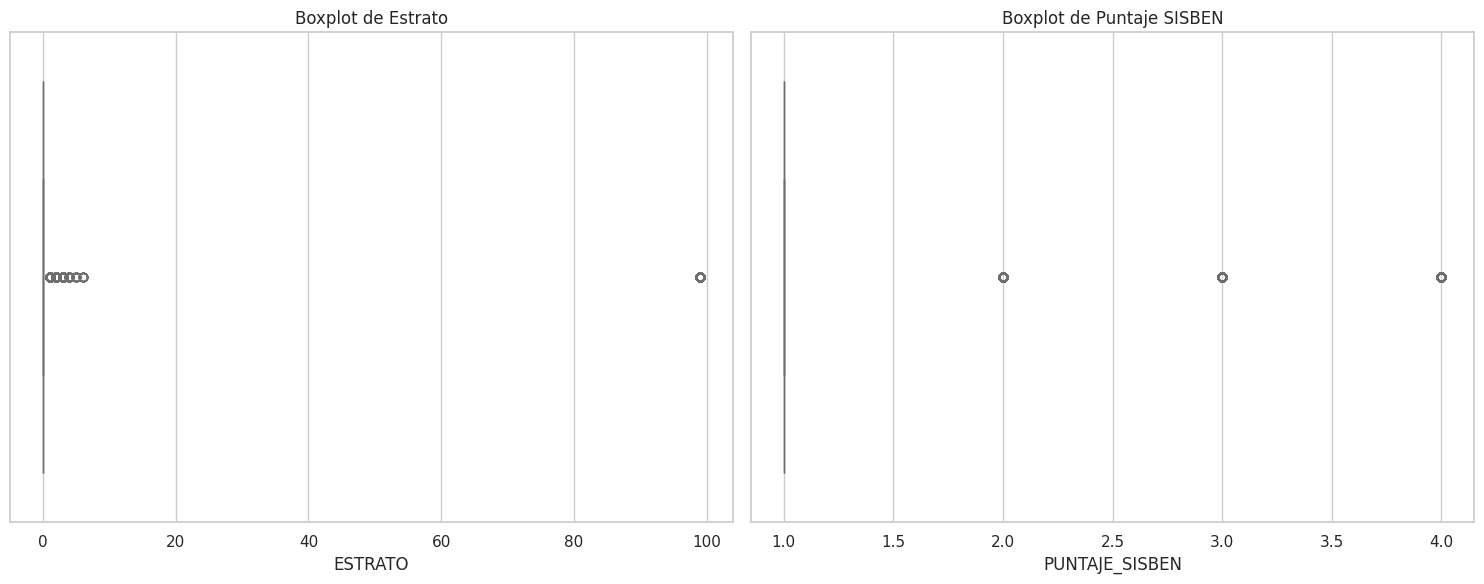

In [15]:
# Convertimos a Pandas para graficar
pdf = dfPy02.select("ESTRATO", "PUNTAJE_SISBEN").toPandas()
sns.set_theme(style="whitegrid")

# --- FIGURA DE BOXPLOTS ---
fig_box, axes_box = plt.subplots(1, 2, figsize=(15, 6))

sns.boxplot(x=pdf['ESTRATO'], ax=axes_box[0], color='skyblue')
axes_box[0].set_title('Boxplot de Estrato')

sns.boxplot(x=pdf['PUNTAJE_SISBEN'], ax=axes_box[1], color='salmon')
axes_box[1].set_title('Boxplot de Puntaje SISBEN')

plt.tight_layout()
plt.show()

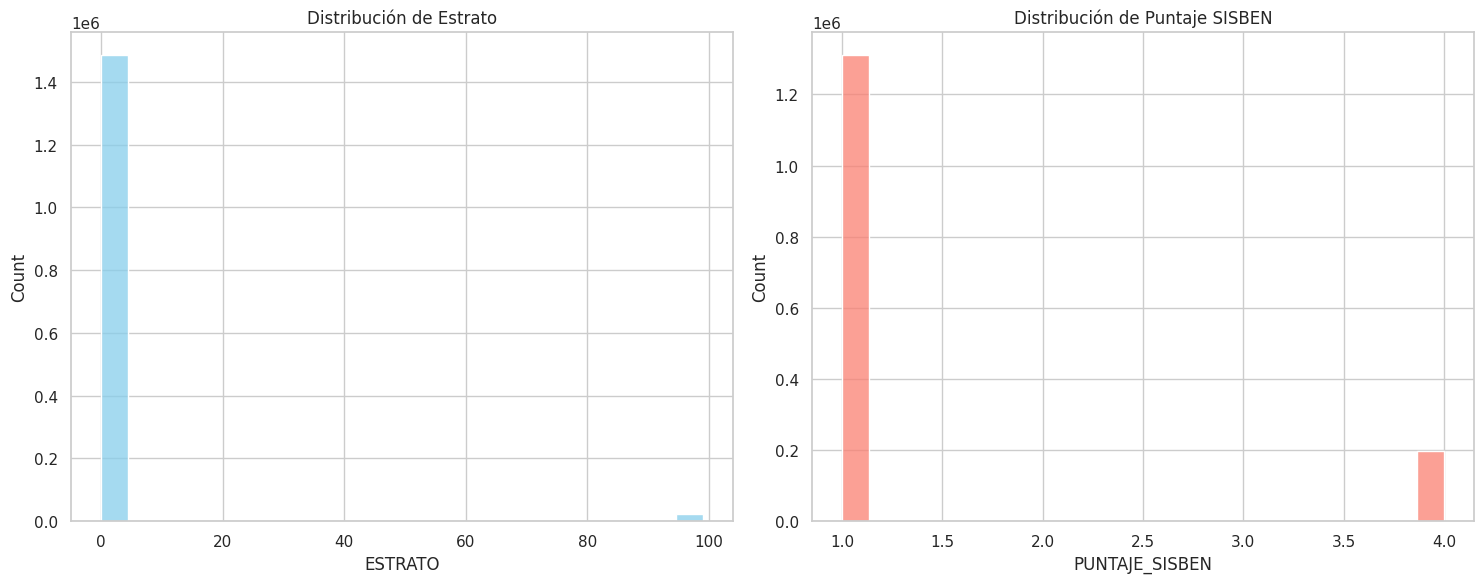

In [16]:
# --- FIGURA DE HISTOGRAMAS ---
fig_hist, axes_hist = plt.subplots(1, 2, figsize=(15, 6))

sns.histplot(pdf['ESTRATO'].dropna(), ax=axes_hist[0], color='skyblue')
axes_hist[0].set_title('Distribución de Estrato')

sns.histplot(pdf['PUNTAJE_SISBEN'].dropna(), ax=axes_hist[1], color='salmon')
axes_hist[1].set_title('Distribución de Puntaje SISBEN')

plt.tight_layout()
plt.show()

Se visualiza en los boxplots e histogramas la distribución del Estrato y el Puntaje SISBEN. Al tratarse de una población en situación de vulnerabilidad, se espera que la mayoría de los registros se concentren en estratos bajos y puntajes SISBEN reducidos. La presencia de valores atípicos puede indicar inconsistencias en la captura de datos o casos especiales dentro del programa.

/tmp/ipykernel_2273024/2539836760.py:8: FutureWarning:                          

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=genero_counts.index, y=genero_counts.values, ax=axes[0], palette='pastel')
/tmp/ipykernel_2273024/2539836760.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=edad_counts.index, y=edad_counts.values, ax=axes[1], palette='pastel')


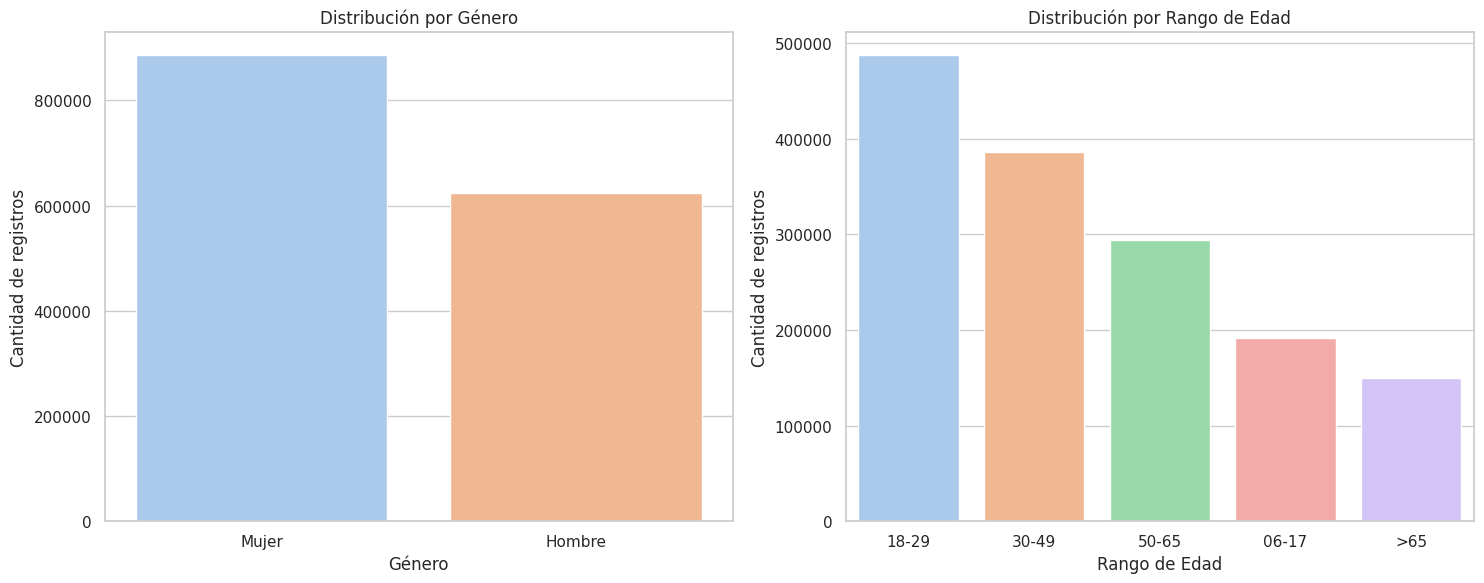

In [17]:
# Distribución de beneficiarios por GÉNERO y RANGO_EDAD
pdf_cat = dfPy02.select("GENERO", "RANGO_EDAD").toPandas()

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Gráfico de barras por Género
genero_counts = pdf_cat['GENERO'].value_counts()
sns.barplot(x=genero_counts.index, y=genero_counts.values, ax=axes[0], palette='pastel')
axes[0].set_title('Distribución por Género')
axes[0].set_xlabel('Género')
axes[0].set_ylabel('Cantidad de registros')

# Gráfico de barras por Rango de Edad
edad_counts = pdf_cat['RANGO_EDAD'].value_counts()
sns.barplot(x=edad_counts.index, y=edad_counts.values, ax=axes[1], palette='pastel')
axes[1].set_title('Distribución por Rango de Edad')
axes[1].set_xlabel('Rango de Edad')
axes[1].set_ylabel('Cantidad de registros')

plt.tight_layout()
plt.show()

In [18]:
## Cálculo de la correlación entre el Estrato y el Puntaje SISBEN
# Preparamos los datos eliminando nulos
df_temp = pdf[['ESTRATO', 'PUNTAJE_SISBEN']].dropna()

# Calculamos Spearman y el p-valor
coef_spearman, p_valor = stats.spearmanr(df_temp['ESTRATO'], df_temp['PUNTAJE_SISBEN'])

# Mostrar resultados formateados
print("--- Prueba de Correlación de Spearman ---")
print(f"Coeficiente de correlación (rho): {coef_spearman:.4f}")
print(f"P-valor: {p_valor:.4e}")

# Interpretación automática
alpha = 0.05
if p_valor < alpha:
    print("\nInterpretación: La correlación es ESTADÍSTICAMENTE SIGNIFICATIVA.")
    print(f"Hay evidencia suficiente para rechazar la hipótesis nula (p < {alpha}).")
else:
    print("\nInterpretación: La correlación NO es estadísticamente significativa.")
    print("No hay evidencia suficiente para afirmar que existe una relación (p > 0.05).")

--- Prueba de Correlación de Spearman ---
Coeficiente de correlación (rho): -0.1595
P-valor: 0.0000e+00

Interpretación: La correlación es ESTADÍSTICAMENTE SIGNIFICATIVA.
Hay evidencia suficiente para rechazar la hipótesis nula (p < 0.05).


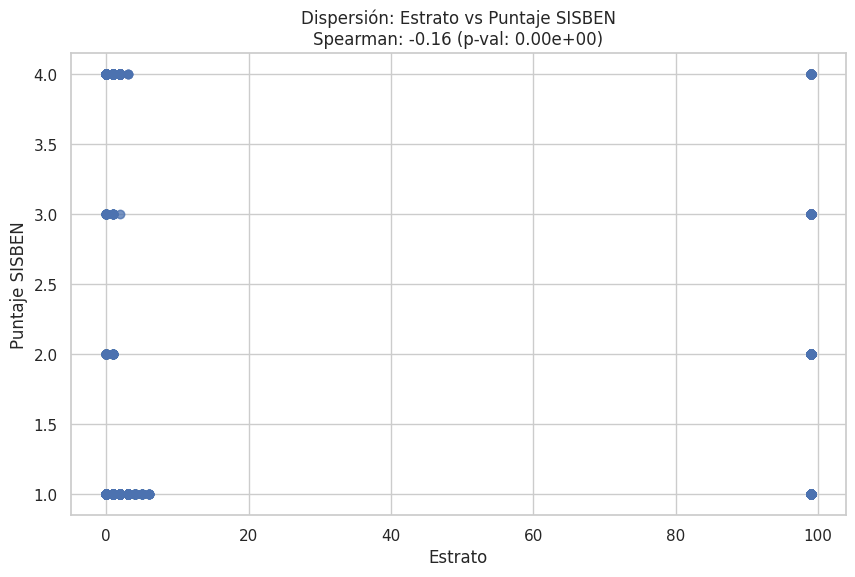

In [19]:
# --- DIAGRAMA DE DISPERSIÓN (Relación Estrato vs Puntaje SISBEN) ---
plt.figure(figsize=(10, 6))
sns.regplot(data=pdf, x='ESTRATO', y='PUNTAJE_SISBEN',
            fit_reg=False, scatter_kws={'alpha':0.5})
plt.title(f'Dispersión: Estrato vs Puntaje SISBEN\nSpearman: {coef_spearman:.2f} (p-val: {p_valor:.2e})')
plt.xlabel('Estrato')
plt.ylabel('Puntaje SISBEN')
plt.show()

El análisis exploratorio permite identificar la relación entre el estrato socioeconómico y el puntaje SISBEN de los beneficiarios. La correlación de Spearman indica si existe una asociación monótona entre estas variables, lo cual es relevante para entender los perfiles de vulnerabilidad dentro del programa UNIDOS y su posible impacto en indicadores educativos como los resultados ICFES.

## **Reporte de calidad**

In [20]:
## Version
dfPy03 = dfPy02

In [21]:
# Duplicados
dfPy03 = dfPy03.distinct()
print("Registros tras eliminar duplicados:", dfPy03.count())

[Stage 44:===========================================>            (10 + 3) / 13]

Registros tras eliminar duplicados: 1503388


In [22]:
# Eliminación de registros con GÉNERO nulo
dfPy03 = dfPy03.filter(F.col("GENERO").isNotNull())
print("Registros tras eliminar nulos en GENERO:", dfPy03.count())

[Stage 50:===========================================>            (10 + 3) / 13]

Registros tras eliminar nulos en GENERO: 1503283


In [23]:
# Descarte de columnas con alta ausencia
columnas_a_descartar = ["PAIS", "ETNIA", "TIENE_SISBEN", "ORIENT_SEXUAL"]
dfPy03 = dfPy03.drop(*columnas_a_descartar)
print("Columnas restantes:", dfPy03.columns)

Columnas restantes: ['ID_FAMILIA', 'TIPO_DOC', 'RANGO_EDAD', 'COD_DEP', 'NOM_DEP', 'COD_MUN', 'NOM_MUN', 'PUNTAJE_SISBEN', 'DISCAPACIDAD', 'ESTADO_CIVIL', 'ESTRATO', 'GENERO', 'PARENTESCO', 'TIPO_POBLACION', 'ESTADO_BENEF', 'Logro1', 'Logro2', 'Logro3', 'Logro4', 'Logro5', 'Logro6', 'Logro7', 'Logro8', 'Logro9', 'Logro10', 'Logro11', 'Logro12', 'Logro13', 'Logro14', 'Logro15', 'Logro16', 'Logro17', 'Logro18', 'Logro19', 'Logro20', 'Logro21', 'Logro22', 'Logro23', 'Logro24', 'Logro25', 'Logro26', 'PE34', 'PE35', 'PE36', 'PE37', 'PE38', 'PE39', 'PE40', 'PE41', 'PE42', 'PE43', 'PE44', 'PE45', 'PE46', 'PE48', 'PE50', 'PE51', 'HE11', 'HE12', 'HE13', 'HE14', 'HE15', 'HE16', 'HE17', 'HE18', 'HE20', 'HE21', 'HE22', 'HE23']


In [24]:
# Ver todos los valores en PARENTESCO
dfPy03.groupby("PARENTESCO").count().orderBy("count", ascending=False).show(100, truncate=False)

[Stage 56:===========================================>            (10 + 3) / 13]

+------------------------+------+
|PARENTESCO              |count |
+------------------------+------+
|JEFE                    |352978|
|HIJOS/ HIJASTROS        |341842|
|HIJOS / HIJASTROS       |297241|
|CÓNYUGE O COMPAÑERA(O)  |160209|
|CÓNYUGE O COMPAÑERA (O) |108878|
|NULL                    |105994|
|NIETOS                  |53157 |
|HIJO(A) / HIJASTRO(A)   |19991 |
|JEFE DEL HOGAR          |14781 |
|PADRES                  |10516 |
|CÓNYUGE O COMPAÑERO(A)  |9653  |
|HERMANOS                |8653  |
|SOBRINOS                |5211  |
|YERNO O NUERA           |3186  |
|NIETO(A)                |2279  |
|OTROS NO PARIENTES      |2041  |
|OTROS PARIENTES         |1989  |
|SUEGROS                 |917   |
|CUÑADOS                 |713   |
|ABUELOS                 |650   |
|PADRE / MADRE           |556   |
|HERMANO(A)              |390   |
|TÍOS                    |357   |
|PRIMOS                  |337   |
|SOBRINO(A)              |200   |
|HIJO(A)/ HIJASTRO(A)    |151   |
|YERNO / NUERA

In [25]:
# Consolidación mejorada de categorías en PARENTESCO
dfPy03 = dfPy03.withColumn("PARENTESCO",
    F.when(F.col("PARENTESCO").isin(
        "HIJOS/ HIJASTROS", "HIJOS / HIJASTROS", "HIJO(A) / HIJASTRO(A)", 
        "HIJO(A)/ HIJASTRO(A)", "NIETOS", "NIETO(A)"
    ), "HIJOS_O_DESCENDIENTES")
    .when(F.col("PARENTESCO").isin(
        "CÓNYUGE O COMPAÑERA(O)", "CÓNYUGE O COMPAÑERA (O)", 
        "CÓNYUGE O COMPAÑERO(A)", "CÓNYUGE O COMPAÑERA"
    ), "CONYUGE_O_COMPANERO")
    .when(F.col("PARENTESCO").isin("JEFE", "JEFE DEL HOGAR"), "JEFE_HOGAR")
    .when(F.col("PARENTESCO").isin("PADRES", "PADRE / MADRE", "PADRE/ MADRE", "ABUELOS", "ABUELO(A)"), "ASCENDIENTES")
    .when(F.col("PARENTESCO").isin("HERMANOS", "HERMANO(A)"), "HERMANOS")
    .when(F.col("PARENTESCO").isin("YERNO O NUERA", "YERNO / NUERA"), "YERNO_NUERA")
    .when(F.col("PARENTESCO").isin(
        "SOBRINOS", "SOBRINO(A)", "TÍOS", "TÍO(A)", "PRIMOS", "PRIMO(A)", 
        "SUEGROS", "SUEGRO(A)", "CUÑADOS", "CUÑADO(A)", "OTROS PARIENTE", "OTRO PARIENTE"
    ), "OTROS_PARIENTES")
    .when(F.col("PARENTESCO").isin(
        "OTROS NO PARIENTES", "NO PARIENTE", "PENSIONISTA", "EMPLEADO SERV. DOMÉSTICO"
    ), "NO_PARIENTES")
    .when(F.col("PARENTESCO").isin("NA", "NULL", "") | F.col("PARENTESCO").isNull(), "SIN_DATO")
    .otherwise(F.col("PARENTESCO"))
)

print("Categorías de PARENTESCO tras consolidación mejorada:")
dfPy03.groupby("PARENTESCO").count().orderBy(F.col("count").desc()).show(truncate=False)

Categorías de PARENTESCO tras consolidación mejorada:


[Stage 62:===============================================>        (11 + 2) / 13]

+---------------------+------+
|PARENTESCO           |count |
+---------------------+------+
|HIJOS_O_DESCENDIENTES|714661|
|JEFE_HOGAR           |367759|
|CONYUGE_O_COMPANERO  |278740|
|SIN_DATO             |106000|
|ASCENDIENTES         |11763 |
|HERMANOS             |9043  |
|OTROS_PARIENTES      |7957  |
|YERNO_NUERA          |3294  |
|NO_PARIENTES         |2077  |
|OTROS PARIENTES      |1989  |
+---------------------+------+



In [26]:
# Imputación de PUNTAJE_SISBEN por GENERO y RANGO_EDAD
rangos_edad = ["18-29", "30-49", "50-65", ">65"] 
generos = ["Hombre", "Mujer"]

# Se construye un diccionario de promedios: {(genero, rango): promedio}
promedios_sisben = {}

for genero in generos:
    for rango in rangos_edad:
        resultado = (
            dfPy03
            .where(
                (F.col("GENERO") == F.lit(genero)) &
                (F.col("RANGO_EDAD") == F.lit(rango)) &
                F.col("PUNTAJE_SISBEN").isNotNull()
            )
            .select(F.mean(F.col("PUNTAJE_SISBEN")))
            .collect()
        )
        valor = resultado[0][0]
        # Se usa el round nativo de Python para evitar conflicto con F.round
        promedios_sisben[(genero, rango)] = __builtins__.round(valor, 2) if valor is not None else None

# Verificación de promedios calculados
for k, v in promedios_sisben.items():
    print(f"  Promedio SISBEN | Género: {k[0]:6s} | Rango: {k[1]:6s} → {v}")

[Stage 108:=============================================>         (10 + 2) / 12]

  Promedio SISBEN | Género: Hombre | Rango: 18-29  → 1.45
  Promedio SISBEN | Género: Hombre | Rango: 30-49  → 1.14
  Promedio SISBEN | Género: Hombre | Rango: 50-65  → 1.1
  Promedio SISBEN | Género: Hombre | Rango: >65    → 1.07
  Promedio SISBEN | Género: Mujer  | Rango: 18-29  → 1.45
  Promedio SISBEN | Género: Mujer  | Rango: 30-49  → 1.56
  Promedio SISBEN | Género: Mujer  | Rango: 50-65  → 1.37
  Promedio SISBEN | Género: Mujer  | Rango: >65    → 1.24


In [27]:
# Se construye la expresión de imputación condicional
condicion_imputacion = F.col("PUNTAJE_SISBEN")  # valor base

for (genero, rango), promedio in promedios_sisben.items():
    if promedio is not None:
        condicion_imputacion = (
            F.when(
                F.col("PUNTAJE_SISBEN").isNull() &
                (F.col("GENERO") == F.lit(genero)) &
                (F.col("RANGO_EDAD") == F.lit(rango)),
                F.lit(promedio)
            )
            .otherwise(condicion_imputacion)
        )

dfPy03 = dfPy03.withColumn("PUNTAJE_SISBEN", condicion_imputacion.cast("int"))

# Verificación: no deben quedar nulos
nulos_restantes = dfPy03.filter(F.col("PUNTAJE_SISBEN").isNull()).count()
print(f"Nulos restantes en PUNTAJE_SISBEN: {nulos_restantes}")

[Stage 114:==================================================>    (11 + 1) / 12]

Nulos restantes en PUNTAJE_SISBEN: 0


In [28]:
# Residuales
dfPy03 = dfPy03.filter(
    col("HE11").isNotNull() &
    col("HE17").isNotNull()
)

In [29]:
# Verificación final
def count_missings(df):
    output = []
    for c, dtype in df.dtypes:
        if dtype in ["double", "float"]:
            output.append(F.count(F.when(F.col(c).isNull() | F.isnan(F.col(c)), c)).alias(c))
        else:
            output.append(F.count(F.when(F.col(c).isNull(), c)).alias(c))
    return output

print("Conteo de nulos tras tratamiento:")
dfPy03.select(count_missings(dfPy03)).show()

print("Total de registros finales:", dfPy03.count())

Conteo de nulos tras tratamiento:


+----------+--------+----------+-------+-------+-------+-------+--------------+------------+------------+-------+------+----------+--------------+------------+------+------+------+------+------+------+------+------+------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+
|ID_FAMILIA|TIPO_DOC|RANGO_EDAD|COD_DEP|NOM_DEP|COD_MUN|NOM_MUN|PUNTAJE_SISBEN|DISCAPACIDAD|ESTADO_CIVIL|ESTRATO|GENERO|PARENTESCO|TIPO_POBLACION|ESTADO_BENEF|Logro1|Logro2|Logro3|Logro4|Logro5|Logro6|Logro7|Logro8|Logro9|Logro10|Logro11|Logro12|Logro13|Logro14|Logro15|Logro16|Logro17|Logro18|Logro19|Logro20|Logro21|Logro22|Logro23|Logro24|Logro25|Logro26|PE34|PE35|PE36|PE37|PE38|PE39|PE40|PE41|PE42|PE43|PE44|PE45|PE46|PE48|PE50|PE51|HE11|HE12|HE13|HE14|HE15|HE16|HE17|HE18|HE20|HE21|HE22|HE23|
+-

[Stage 125:=========================>                              (6 + 7) / 13]

Total de registros finales: 1503267


## **Planteamiento de sub-preguntas investigativas**

1. ¿Existe relación entre el nivel de pobreza extrema (medido por el puntaje SISBEN y el estrato) de un municipio y el rendimiento en las pruebas ICFES de sus estudiantes?
2. ¿Afectan los logros de superación de pobreza de la Estrategia UNIDOS (acceso a salud, educación, vivienda) en el desempeño académico de los jóvenes en Colombia?
3. ¿Qué características sociodemográficas de los beneficiarios del programa UNIDOS (género, rango de edad, parentesco) están más correlacionadas con niveles de pobreza más profunda?
4. ¿Pueden los indicadores de la Estrategia UNIDOS predecir el rendimiento estudiantil en el ICFES a nivel municipal?

## **Limpieza, filtro y transformaciones iniciales**

Dado los resultados obtenidos en el análisis exploratorio, y con el fin de preparar los datos para posibles modelos con supuestos de normalidad, se considera la transformación logarítmica de variables numéricas sesgadas como el PUNTAJE_SISBEN. Se conservarán también los datos base para técnicas sin supuestos de normalidad o para mayor explicabilidad de los modelos.

In [30]:
# Filtramos: eliminamos registros donde PUNTAJE_SISBEN sea 0 o negativo para log-transformación
df_positivos = dfPy03.filter(
    (F.col("PUNTAJE_SISBEN") > 0)
)

# Aplicamos la transformación logarítmica (Logaritmo Natural)
df_log = df_positivos.withColumn("log_puntaje_sisben", F.log("PUNTAJE_SISBEN"))

# Verificamos cuántos datos quedaron después del filtro
conteo_original = dfPy03.count()
conteo_final = df_log.count()

print(f"Filas originales: {conteo_original}")
print(f"Filas tras filtrar ceros: {conteo_final}")
print(f"Registros descartados: {conteo_original - conteo_final}")

# Mostramos una muestra del resultado
df_log.select("ID_FAMILIA", "PUNTAJE_SISBEN", "log_puntaje_sisben").show(5)

# Convertimos a Pandas para gráficas Q-Q
pdf_log = df_log.select("log_puntaje_sisben").toPandas()

Filas originales: 1503267
Filas tras filtrar ceros: 1503267
Registros descartados: 0


+-----------+--------------+------------------+
| ID_FAMILIA|PUNTAJE_SISBEN|log_puntaje_sisben|
+-----------+--------------+------------------+
|HID89293014|             1|               0.0|
|HID31322498|             1|               0.0|
|HID76289104|             1|               0.0|
|HID85629600|             1|               0.0|
|HID55749728|             1|               0.0|
+-----------+--------------+------------------+
only showing top 5 rows



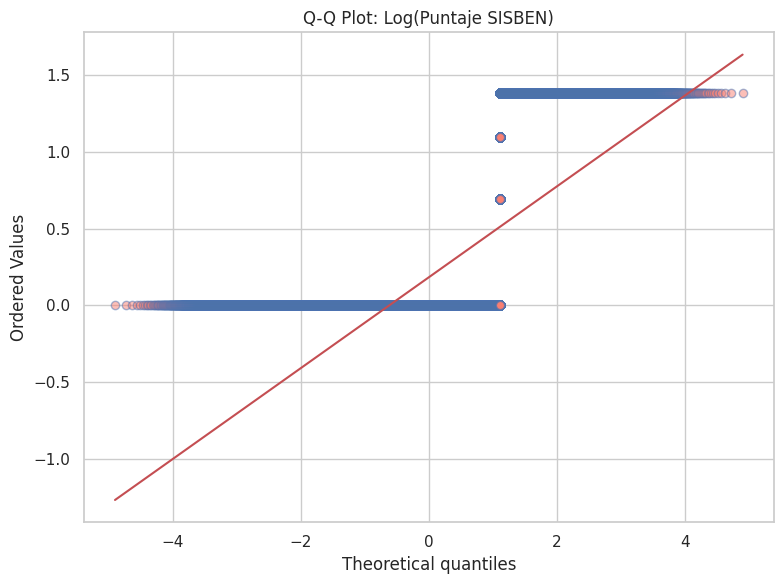

In [31]:
# Graficación de QQ plot filtrado y transformado
fig, ax1 = plt.subplots(1, 1, figsize=(8, 6))

# --- Q-Q Plot Puntaje SISBEN log-transformado ---
stats.probplot(pdf_log["log_puntaje_sisben"].dropna(), dist="norm", plot=ax1)
ax1.set_title('Q-Q Plot: Log(Puntaje SISBEN)')
ax1.get_lines()[0].set_markerfacecolor('salmon')
ax1.get_lines()[0].set_alpha(0.5)

plt.tight_layout()
plt.show()

El gráfico QQ plot permite evaluar si la transformación logarítmica mejora la normalidad del Puntaje SISBEN. Una mejor alineación con la línea teórica indicará que los datos transformados se comportan de forma más cercana a una distribución normal, lo que favorecerá la aplicación de modelos estadísticos paramétricos en fases posteriores del proyecto.